In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Dataset"

print("Dataset exists:", os.path.exists(dataset_path))

print("\nDataset folders:")
print(os.listdir(dataset_path))

Dataset exists: True

Dataset folders:
['test', 'train', 'val']


In [ ]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n===== {split.upper()} =====")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            image_count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            print(f"{class_name}: {image_count}")


===== TRAIN =====
Acne_Mild: 465
Acne_Moderate: 454
Acne_Severe: 454
Eczema_Mild: 454
Eczema_Moderate: 454
Eczema_Severe: 454
Normal: 453
Xyz: 454

===== VAL =====
Acne_Mild: 97
Acne_Moderate: 97
Acne_Severe: 97
Eczema_Mild: 97
Eczema_Moderate: 97
Eczema_Severe: 97
Normal: 98
Xyz: 97

===== TEST =====
Acne_Mild: 99
Acne_Moderate: 99
Acne_Severe: 99
Eczema_Mild: 99
Eczema_Moderate: 99
Eczema_Severe: 99
Normal: 99
Xyz: 99


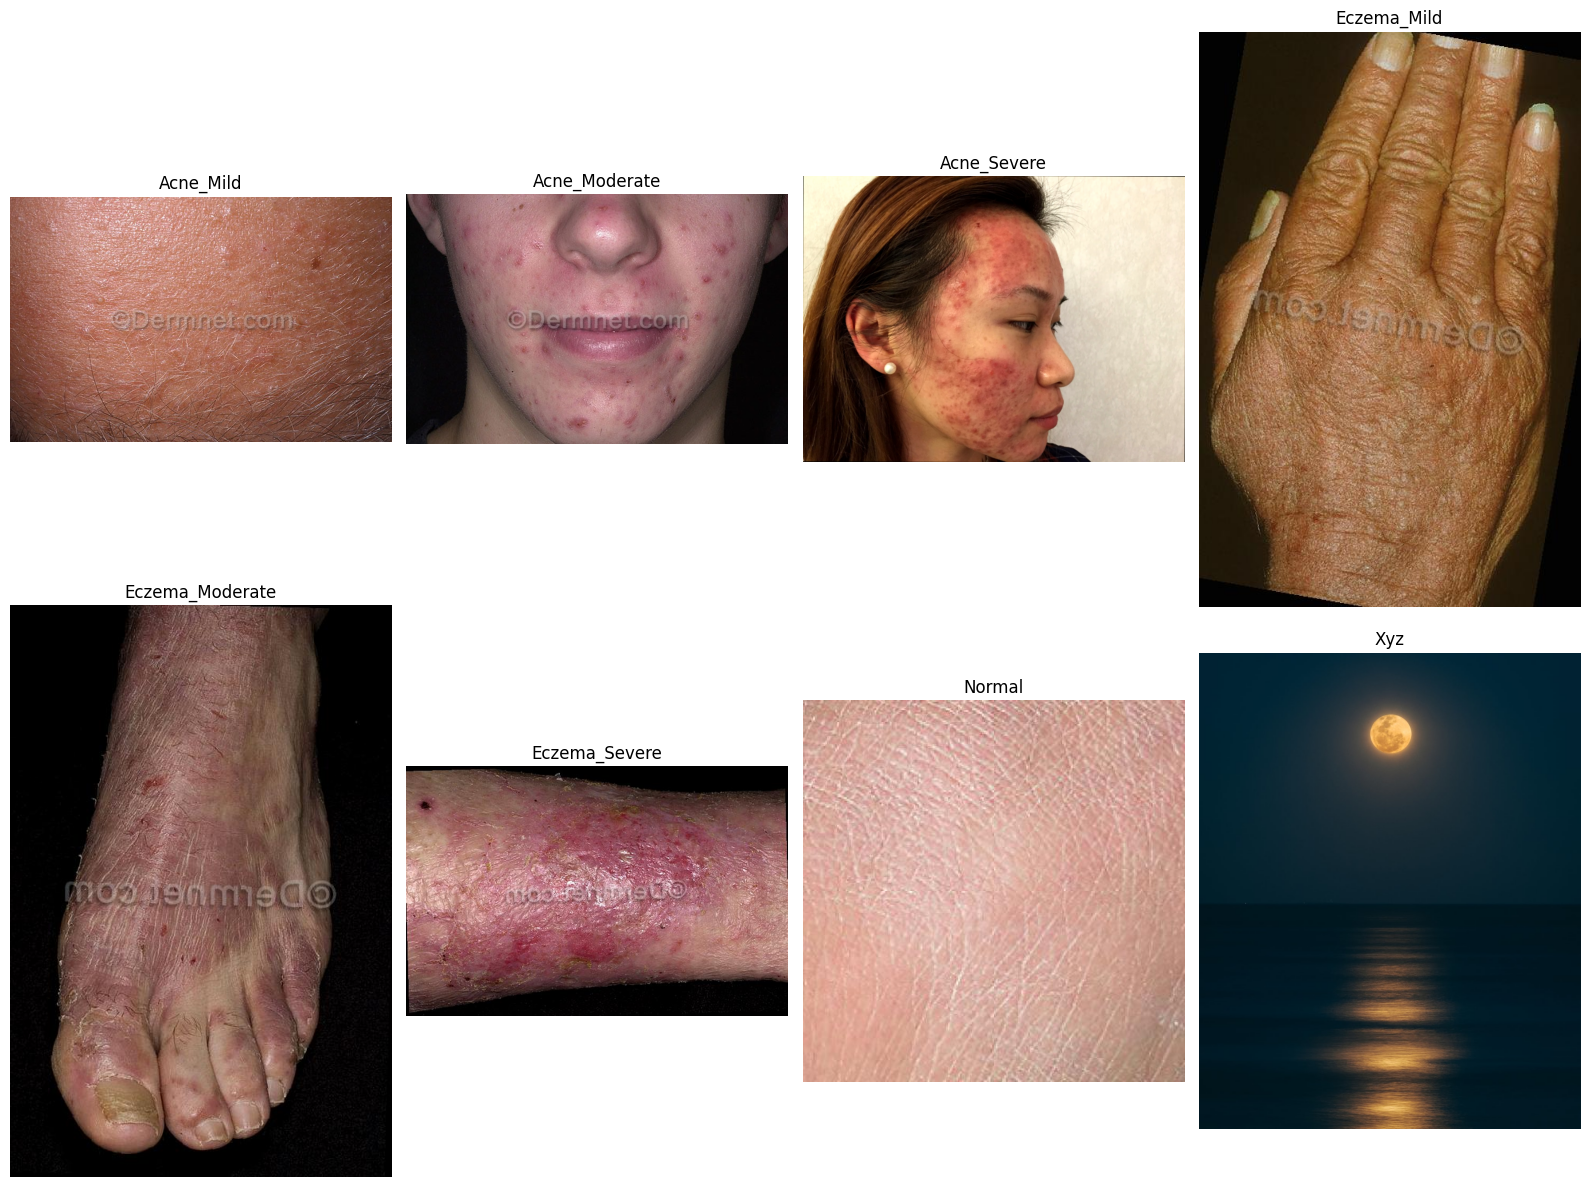

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

train_path = "/content/drive/MyDrive/Dataset/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(16, 12))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Random image
    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
train_dir = "/content/drive/MyDrive/Dataset/train"
val_dir = "/content/drive/MyDrive/Dataset/val"
test_dir = "/content/drive/MyDrive/Dataset/test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training: augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

# Validation/Test: only normalization
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Data generators created successfully!")

Data generators created successfully!


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 3642 images belonging to 8 classes.
Found 777 images belonging to 8 classes.
Found 792 images belonging to 8 classes.

Class indices:
{'Acne_Mild': 0, 'Acne_Moderate': 1, 'Acne_Severe': 2, 'Eczema_Mild': 3, 'Eczema_Moderate': 4, 'Eczema_Severe': 5, 'Normal': 6, 'Xyz': 7}


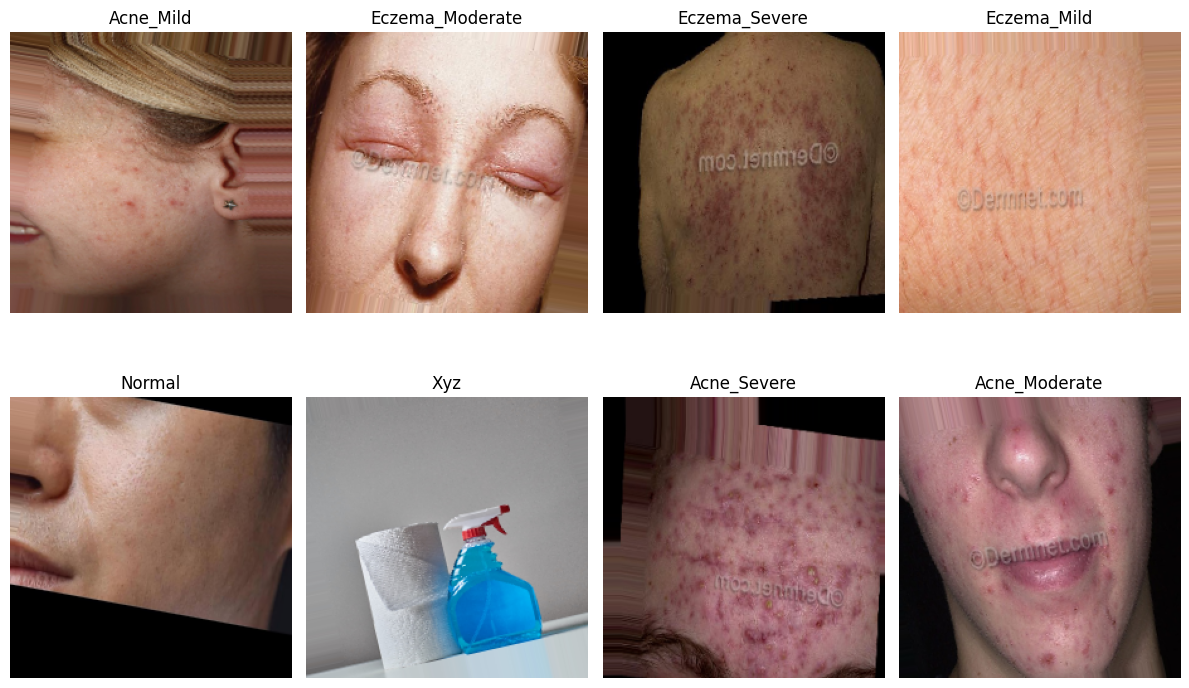

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])

    class_index = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow version:", tf.__version__)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully!")

TensorFlow version: 2.20.0
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully!


In [ ]:
# Freeze the pretrained MobileNetV2 layers
base_model.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 0


In [ ]:
# Build the classification head

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(8, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_skin_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3714 - loss: 1.7045 
Epoch 1: val_loss improved from None to 1.05109, saving model to /content/drive/MyDrive/best_skin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_skin_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 1506s 13s/step - accuracy: 0.4621 - loss: 1.3970 - val_accuracy: 0.5483 - val_loss: 1.0511
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5646 - loss: 1.0516
Epoch 2: val_loss improved from 1.05109 to 0.94397, saving model to /content/drive/MyDrive/best_skin_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_skin_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.5865 - loss: 1.0240 - val_accuracy: 0.6100 - val_loss: 0.9440
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6166 - loss: 0.9537
Epoch 3: val_loss improved from 0.94397 to 0.94139, saving model to /content/drive/MyDrive/best_skin_model.keras

Epoch 3:

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

print("Best model loaded fresh!")

Best model loaded fresh!


In [ ]:
best_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

25/25 ━━━━━━━━━━━━━━━━━━━━ 255s 10s/step - accuracy: 0.6919 - loss: 0.7642
Test Loss: 0.7641938328742981
Test Accuracy: 0.691919207572937
Test Accuracy (%): 69.1919207572937


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step


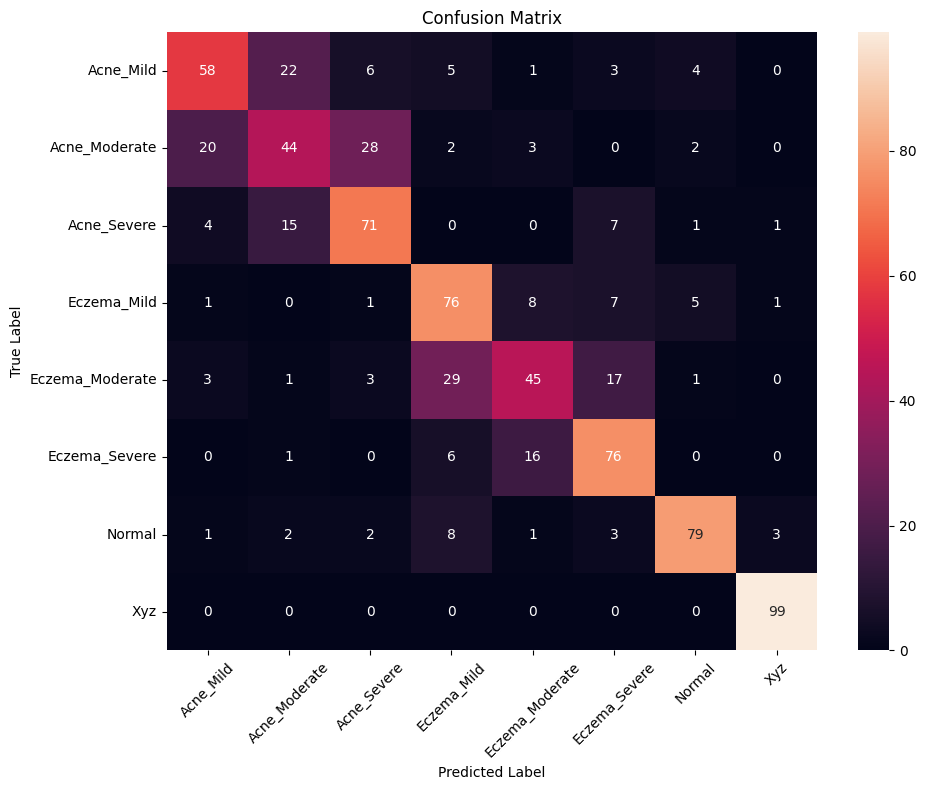

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    'Acne_Mild',
    'Acne_Moderate',
    'Acne_Severe',
    'Eczema_Mild',
    'Eczema_Moderate',
    'Eczema_Severe',
    'Normal',
    'Xyz'
]

# Reset test generator
test_generator.reset()

# Predictions
y_pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                 precision    recall  f1-score   support

      Acne_Mild     0.6667    0.5859    0.6237        99
  Acne_Moderate     0.5176    0.4444    0.4783        99
    Acne_Severe     0.6396    0.7172    0.6762        99
    Eczema_Mild     0.6032    0.7677    0.6756        99
Eczema_Moderate     0.6081    0.4545    0.5202        99
  Eczema_Severe     0.6726    0.7677    0.7170        99
         Normal     0.8587    0.7980    0.8272        99
            Xyz     0.9519    1.0000    0.9754        99

       accuracy                         0.6919       792
      macro avg     0.6898    0.6919    0.6867       792
   weighted avg     0.6898    0.6919    0.6867       792



25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step
Total test images: 792
Wrong predictions: 244
Correct predictions: 548


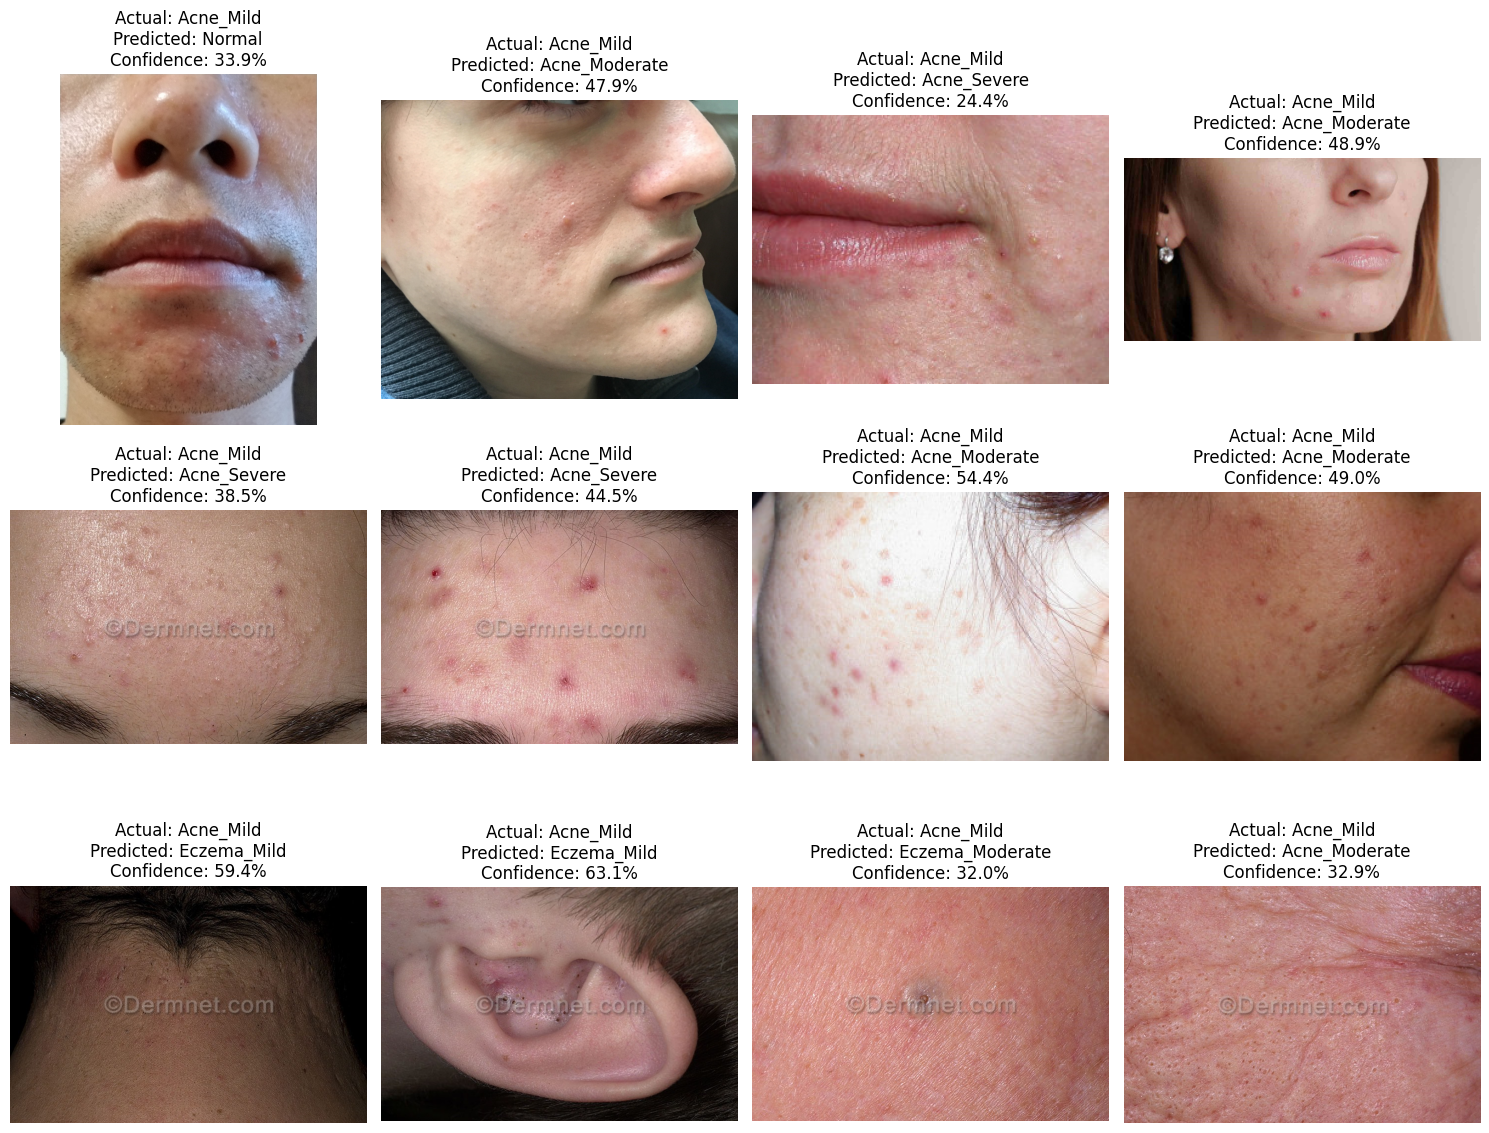

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reset test generator
test_generator.reset()

# Get predictions
y_pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Find wrong predictions
wrong_indices = np.where(y_pred != y_true)[0]

print("Total test images:", len(y_true))
print("Wrong predictions:", len(wrong_indices))
print("Correct predictions:", len(y_true) - len(wrong_indices))

# Display first 12 wrong predictions
num_images = min(12, len(wrong_indices))

plt.figure(figsize=(15, 12))

for i in range(num_images):
    idx = wrong_indices[i]

    # Load image from generator file path
    img_path = test_generator.filepaths[idx]
    img = plt.imread(img_path)

    actual_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]
    confidence = np.max(y_pred_probs[idx]) * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.1f}%"
    )

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

# Get all wrong prediction pairs
wrong_pairs = []

for true_label, pred_label in zip(y_true, y_pred):
    if true_label != pred_label:
        wrong_pairs.append(
            (class_names[true_label], class_names[pred_label])
        )

# Count each confusion pair
pair_counts = Counter(wrong_pairs)

print("Top Confusion Pairs:\n")

for (actual, predicted), count in pair_counts.most_common():
    print(f"{actual}  →  {predicted} : {count}")

Top Confusion Pairs:

Eczema_Moderate  →  Eczema_Mild : 29
Acne_Moderate  →  Acne_Severe : 28
Acne_Mild  →  Acne_Moderate : 22
Acne_Moderate  →  Acne_Mild : 20
Eczema_Moderate  →  Eczema_Severe : 17
Eczema_Severe  →  Eczema_Moderate : 16
Acne_Severe  →  Acne_Moderate : 15
Eczema_Mild  →  Eczema_Moderate : 8
Normal  →  Eczema_Mild : 8
Acne_Severe  →  Eczema_Severe : 7
Eczema_Mild  →  Eczema_Severe : 7
Acne_Mild  →  Acne_Severe : 6
Eczema_Severe  →  Eczema_Mild : 6
Acne_Mild  →  Eczema_Mild : 5
Eczema_Mild  →  Normal : 5
Acne_Mild  →  Normal : 4
Acne_Severe  →  Acne_Mild : 4
Acne_Mild  →  Eczema_Severe : 3
Acne_Moderate  →  Eczema_Moderate : 3
Eczema_Moderate  →  Acne_Mild : 3
Eczema_Moderate  →  Acne_Severe : 3
Normal  →  Eczema_Severe : 3
Normal  →  Xyz : 3
Acne_Moderate  →  Eczema_Mild : 2
Acne_Moderate  →  Normal : 2
Normal  →  Acne_Severe : 2
Normal  →  Acne_Moderate : 2
Acne_Mild  →  Eczema_Moderate : 1
Acne_Severe  →  Normal : 1
Acne_Severe  →  Xyz : 1
Eczema_Mild  →  Acne_Severe 

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image
import os

print("Grad-CAM libraries loaded successfully!")

Grad-CAM libraries loaded successfully!


In [ ]:
# Find the last convolutional layer inside MobileNetV2

for layer in best_model.layers:
    print(layer.name, type(layer).__name__)

mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense
dropout_1 Dropout
dense_1 Dense


In [ ]:
# Find convolutional layers inside MobileNetV2

base_model = best_model.get_layer("mobilenetv2_1.00_224")

for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last convolutional layer:", layer.name)
        break

Last convolutional layer: Conv_1


In [ ]:
# Build/call the loaded model once
_ = best_model(tf.zeros((1, 224, 224, 3)))

print("Best model built successfully!")
print("Model input shape:", best_model.input_shape)
print("Model output shape:", best_model.output_shape)

Best model built successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 8)


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Get MobileNetV2
    base_model = model.get_layer("mobilenetv2_1.00_224")

    # Find the last convolutional layer
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Model that outputs feature maps from the selected layer
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:

        # Get feature maps
        conv_outputs = conv_model(img_array)

        # Continue through the remaining MobileNetV2 layers
        x = conv_outputs

        start_index = base_model.layers.index(last_conv_layer) + 1

        for layer in base_model.layers[start_index:]:
            x = layer(x)

        # Continue through classification head
        x = model.get_layer("global_average_pooling2d")(x)
        x = model.get_layer("dropout")(x, training=False)
        x = model.get_layer("dense")(x)
        x = model.get_layer("dropout_1")(x, training=False)
        predictions = model.get_layer("dense_1")(x)

        # Predicted class
        predicted_class = tf.argmax(predictions[0])

        # Score of predicted class
        class_score = predictions[:, predicted_class]

    # Gradients
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    )

    return heatmap.numpy(), int(predicted_class)

In [ ]:
# Fresh predictions
test_generator.reset()

fresh_probs = best_model.predict(test_generator, verbose=0)
fresh_pred = np.argmax(fresh_probs, axis=1)
fresh_true = test_generator.classes

# Find correctly predicted images
correct_indices = np.where(fresh_pred == fresh_true)[0]

print("Total correct predictions:", len(correct_indices))

# Take the first correct prediction
idx = correct_indices[0]

print("\nSelected image index:", idx)
print("Image:", test_generator.filepaths[idx].split("/")[-1])
print("Actual:", class_names[fresh_true[idx]])
print("Predicted:", class_names[fresh_pred[idx]])
print("Confidence:", f"{np.max(fresh_probs[idx]) * 100:.2f}%")

Total correct predictions: 548

Selected image index: 0
Image: 182.JPG
Actual: Acne_Mild
Predicted: Acne_Mild
Confidence: 80.11%


In [ ]:
# Select the correct image again

test_generator.reset()

fresh_probs = best_model.predict(test_generator, verbose=0)
fresh_pred = np.argmax(fresh_probs, axis=1)
fresh_true = test_generator.classes

# Find correct predictions
correct_indices = np.where(fresh_pred == fresh_true)[0]

idx = correct_indices[0]

img_path = test_generator.filepaths[idx]

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)


img_array = np.array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)
# Generate Grad-CAM
heatmap, predicted_class = make_gradcam_heatmap(
    img_array,
    best_model,
    "Conv_1"
)

prediction = best_model.predict(img_array, verbose=0)
confidence = np.max(prediction) * 100

print("Image:", os.path.basename(img_path))
print("Actual:", class_names[fresh_true[idx]])
print("Predicted:", class_names[predicted_class])
print(f"Confidence: {confidence:.2f}%")

Image: 182.JPG
Actual: Acne_Mild
Predicted: Acne_Mild
Confidence: 80.11%


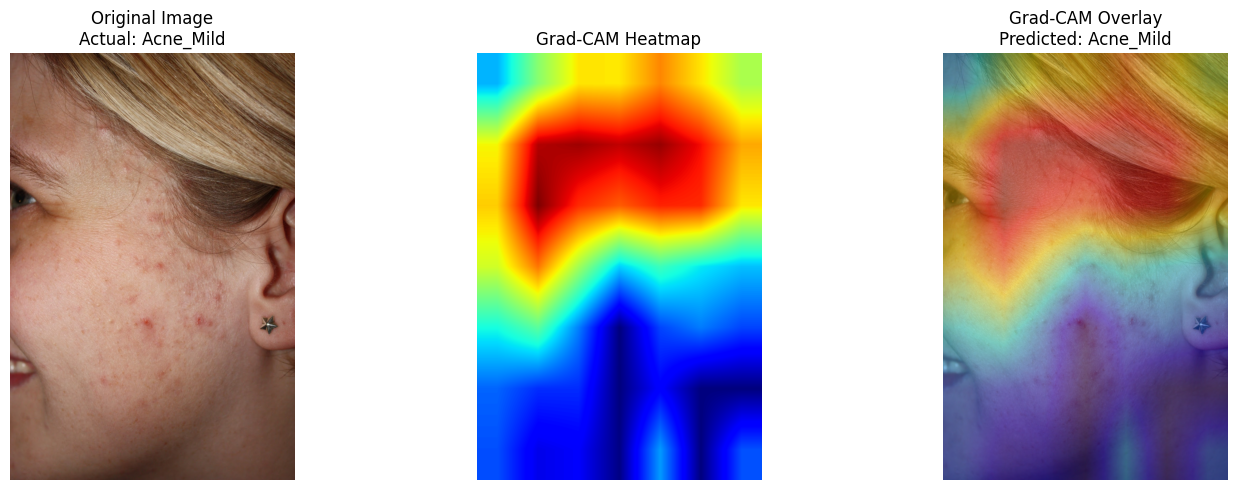

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load original image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize Grad-CAM heatmap to image size
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay heatmap on original image
overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(
    f"Original Image\n"
    f"Actual: {class_names[fresh_true[idx]]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Find wrong predictions
wrong_indices = np.where(fresh_pred != fresh_true)[0]

print("Total wrong predictions:", len(wrong_indices))

# Select the first wrong prediction
wrong_idx = wrong_indices[0]

print("\nSelected wrong prediction:")
print("Image:", test_generator.filepaths[wrong_idx].split("/")[-1])
print("Actual:", class_names[fresh_true[wrong_idx]])
print("Predicted:", class_names[fresh_pred[wrong_idx]])
print(
    "Confidence:",
    f"{np.max(fresh_probs[wrong_idx]) * 100:.2f}%"
)

Total wrong predictions: 244

Selected wrong prediction:
Image: 20190716_191036.jpg.705bf02f23326951059a91a967959d07.jpg
Actual: Acne_Mild
Predicted: Normal
Confidence: 33.87%


In [ ]:
# Select the wrong prediction image

img_path = test_generator.filepaths[wrong_idx]

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224, 224)
)

img_array = np.array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Generate Grad-CAM
heatmap, predicted_class = make_gradcam_heatmap(
    img_array,
    best_model,
    "Conv_1"
)

prediction = best_model.predict(img_array, verbose=0)
confidence = np.max(prediction) * 100

print("Image:", os.path.basename(img_path))
print("Actual:", class_names[fresh_true[wrong_idx]])
print("Predicted:", class_names[predicted_class])
print(f"Prediction confidence: {confidence:.2f}%")

Image: 20190716_191036.jpg.705bf02f23326951059a91a967959d07.jpg
Actual: Acne_Mild
Predicted: Normal
Prediction confidence: 33.87%


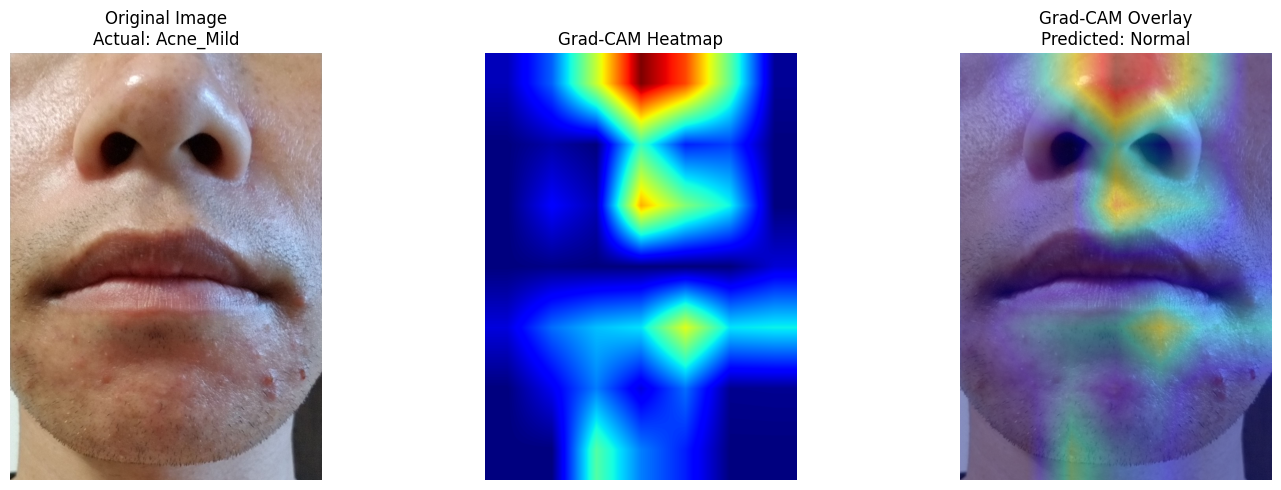

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load original image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Create overlay
overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(
    f"Original Image\n"
    f"Actual: {class_names[fresh_true[wrong_idx]]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

print("Best model loaded successfully!")
print("Input shape:", best_model.input_shape)
print("Output shape:", best_model.output_shape)

Best model loaded successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 8)


In [ ]:
base_model = best_model.get_layer("mobilenetv2_1.00_224")

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Currently trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Total MobileNetV2 layers: 154
Currently trainable layers: 1


In [ ]:
# Unfreeze MobileNetV2
base_model.trainable = True

# Freeze the first 134 layers
for layer in base_model.layers[:134]:
    layer.trainable = False

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Currently trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Total MobileNetV2 layers: 154
Currently trainable layers: 20


In [ ]:
# Recompile the model with a very small learning rate
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [ ]:
history_fine = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1605 - loss: 9.2449

KeyboardInterrupt: 

In [ ]:
# Keep BatchNormalization layers frozen during fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable layers after freezing BatchNormalization:",
      sum(layer.trainable for layer in base_model.layers))

Trainable layers after freezing BatchNormalization: 13


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_finetuned_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

print(callbacks)
print("Callbacks created successfully!")

[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7879d2a4df90>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7879d2a4de50>]
Callbacks created successfully!


In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

print("Fine-tuning training completed!")

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 413s 4s/step - accuracy: 0.1439 - loss: 2.4722 - val_accuracy: 0.1866 - val_loss: 2.1301
Epoch 2/10
 21/114 ━━━━━━━━━━━━━━━━━━━━ 3:08 2s/step - accuracy: 0.1634 - loss: 2.3104

KeyboardInterrupt: 

In [ ]:
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

base_model = model.get_layer("mobilenetv2_1.00_224")

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable MobileNetV2 layers:",
      sum(layer.trainable for layer in base_model.layers))

Model input shape: (None, 224, 224, 3)
Model output shape: (None, 8)
Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 0


In [ ]:
base_model.trainable = True

# First 141 layers freeze
for layer in base_model.layers[:141]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable MobileNetV2 layers:",
      sum(layer.trainable for layer in base_model.layers))

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 8


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_finetuned_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    callbacks=callbacks
)

print("1-epoch fine-tuning test completed!")

 37/114 ━━━━━━━━━━━━━━━━━━━━ 16:45 13s/step - accuracy: 0.1319 - loss: 2.5408

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

print("Working baseline model loaded!")
print("Input shape:", best_model.input_shape)
print("Output shape:", best_model.output_shape)

Working baseline model loaded!
Input shape: (None, 224, 224, 3)
Output shape: (None, 8)


In [ ]:
best_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

test_generator.reset()

test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Baseline Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Baseline Test Loss: {test_loss:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6919 - loss: 0.7642
Baseline Test Accuracy: 69.19%
Baseline Test Loss: 0.7642


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(
    enumerate(class_weights_array)
)

print("Class Weights:")
for class_name, weight in zip(train_generator.class_indices.keys(), class_weights_array):
    print(f"{class_name}: {weight:.3f}")

Class Weights:
Acne_Mild: 0.979
Acne_Moderate: 1.003
Acne_Severe: 1.003
Eczema_Mild: 1.003
Eczema_Moderate: 1.003
Eczema_Severe: 1.003
Normal: 1.005
Xyz: 1.003


In [ ]:
base_model = best_model.get_layer("mobilenetv2_1.00_224")

base_model.trainable = True

# Freeze first 134 layers
for layer in base_model.layers[:134]:
    layer.trainable = False

# Freeze BatchNormalization layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 13


In [ ]:
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled with learning rate = 1e-6")

Fine-tuning model compiled with learning rate = 1e-6


In [ ]:
history_finetune = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    callbacks=callbacks
)

print("1-epoch fine-tuning completed!")

114/114 ━━━━━━━━━━━━━━━━━━━━ 1379s 12s/step - accuracy: 0.7139 - loss: 0.7271 - val_accuracy: 0.6654 - val_loss: 0.8170
1-epoch fine-tuning completed!


In [ ]:
test_generator.reset()

fine_test_loss, fine_test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Fine-tuned Test Accuracy: {fine_test_accuracy * 100:.2f}%")
print(f"Fine-tuned Test Loss: {fine_test_loss:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6869 - loss: 0.7639
Fine-tuned Test Accuracy: 68.69%
Fine-tuned Test Loss: 0.7639


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

best_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline model restored successfully!")

Baseline model restored successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

improved_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True
)

train_generator = improved_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

print("Improved training augmentation ready!")

Found 3642 images belonging to 8 classes.
Improved training augmentation ready!


In [ ]:
base_model = best_model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = False

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

print("1-epoch augmentation experiment completed!")

114/114 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.6944 - loss: 0.7803 - val_accuracy: 0.6718 - val_loss: 0.8150
1-epoch augmentation experiment completed!


In [ ]:
best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

print("Original baseline model restored!")

Original baseline model restored!


In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = best_model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = False

improved_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),
    layers.Dropout(0.35),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(8, activation="softmax")
])

print("Improved classification head created!")
improved_model.summary()

Improved classification head created!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,992 (10.02 MB)

 Trainable params: 364,936 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully!")


Improved model compiled successfully!


In [ ]:
history_improved = improved_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

print("1-epoch improved model training completed!")

114/114 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.2262 - loss: 2.3086 - val_accuracy: 0.4324 - val_loss: 1.5853
1-epoch improved model training completed!


In [ ]:
import os
from PIL import Image

folders = {
    "train": train_dir,
    "val": val_dir,
    "test": test_dir
}

for split, folder in folders.items():
    total = 0
    corrupted = 0

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    img.verify()
                total += 1
            except:
                corrupted += 1

    print(f"{split}: Total = {total}, Corrupted = {corrupted}")

train: Total = 3643, Corrupted = 0
val: Total = 777, Corrupted = 0
test: Total = 792, Corrupted = 0


25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step


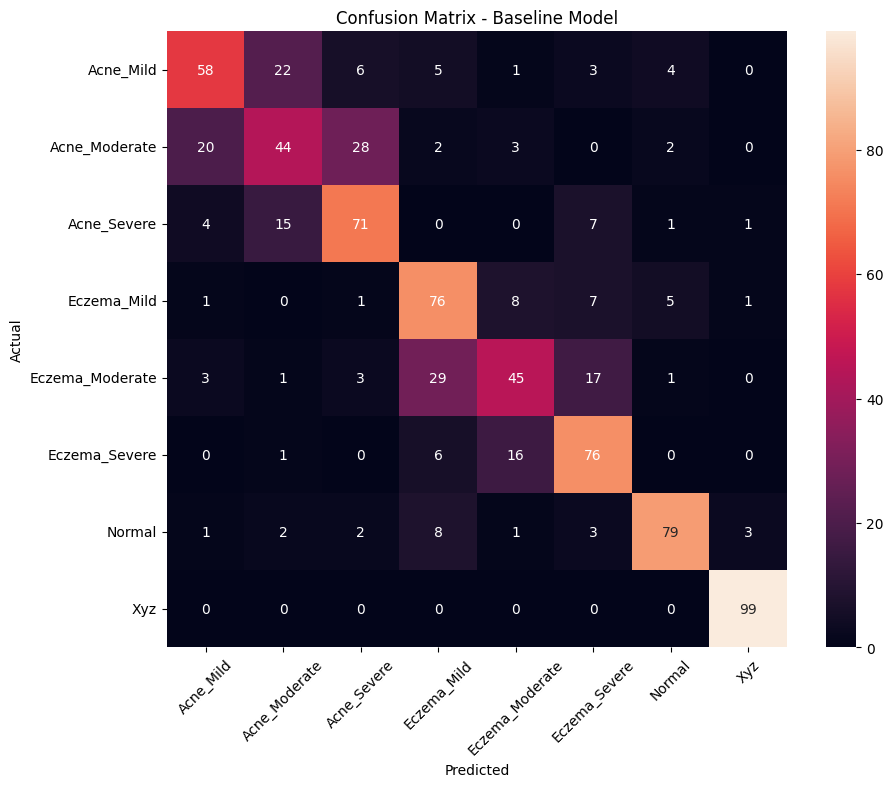

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    'Acne_Mild',
    'Acne_Moderate',
    'Acne_Severe',
    'Eczema_Mild',
    'Eczema_Moderate',
    'Eczema_Severe',
    'Normal',
    'Xyz'
]

test_generator.reset()

y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Original test generator
test_generator.reset()
original_probs = best_model.predict(test_generator, verbose=1)

# Horizontally flipped test images
tta_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

tta_generator = tta_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

tta_generator.reset()
flipped_probs = best_model.predict(tta_generator, verbose=1)

# Average original + flipped predictions
tta_probs = (original_probs + flipped_probs) / 2

# Final predictions
tta_pred = np.argmax(tta_probs, axis=1)
y_true = test_generator.classes

# Accuracy
tta_accuracy = np.mean(tta_pred == y_true)

print(f"\nBaseline Accuracy : {np.mean(np.argmax(original_probs, axis=1) == y_true) * 100:.2f}%")
print(f"TTA Accuracy      : {tta_accuracy * 100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
Found 792 images belonging to 8 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step

Baseline Accuracy : 69.19%
TTA Accuracy      : 69.70%


In [ ]:
from sklearn.metrics import classification_report

# TTA predictions already calculated
tta_pred = np.argmax(tta_probs, axis=1)

print("TTA Classification Report:\n")

print(
    classification_report(
        y_true,
        tta_pred,
        target_names=class_names,
        digits=4
    )
)

TTA Classification Report:

                 precision    recall  f1-score   support

      Acne_Mild     0.6517    0.5859    0.6170        99
  Acne_Moderate     0.5476    0.4646    0.5027        99
    Acne_Severe     0.6339    0.7172    0.6730        99
    Eczema_Mild     0.6129    0.7677    0.6816        99
Eczema_Moderate     0.6197    0.4444    0.5176        99
  Eczema_Severe     0.6752    0.7980    0.7315        99
         Normal     0.8681    0.7980    0.8316        99
            Xyz     0.9519    1.0000    0.9754        99

       accuracy                         0.6970       792
      macro avg     0.6951    0.6970    0.6913       792
   weighted avg     0.6951    0.6970    0.6913       792



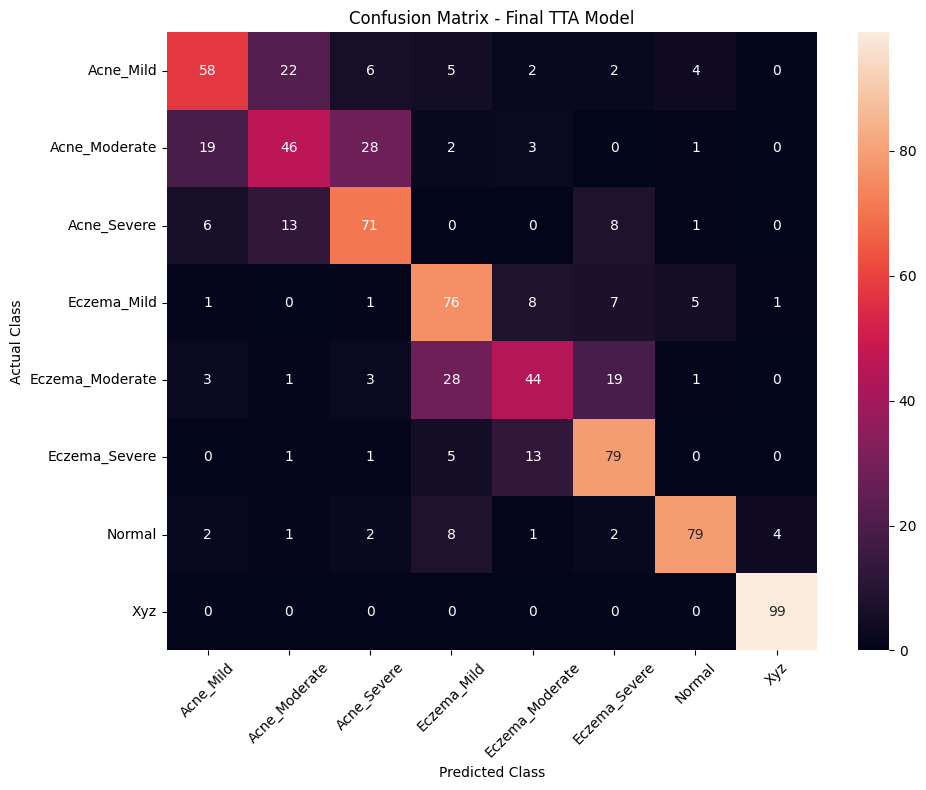

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix using TTA predictions
cm_tta = confusion_matrix(y_true, tta_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_tta,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Final TTA Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# New generators for MobileNetV2 preprocessing
proper_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

proper_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

proper_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

proper_train_generator = proper_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

proper_val_generator = proper_val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

proper_test_generator = proper_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Proper MobileNetV2 preprocessing generators created!")

Found 3642 images belonging to 8 classes.
Found 777 images belonging to 8 classes.
Found 792 images belonging to 8 classes.
Proper MobileNetV2 preprocessing generators created!


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Fresh pretrained MobileNetV2
proper_base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze backbone initially
proper_base_model.trainable = False

# Classification head
proper_model = models.Sequential([
    proper_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="softmax")
])

print("Fresh MobileNetV2 model created!")

Fresh MobileNetV2 model created!


In [ ]:
import tensorflow as tf

proper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Proper MobileNetV2 model compiled successfully!")

Proper MobileNetV2 model compiled successfully!


In [ ]:
history_proper = proper_model.fit(
    proper_train_generator,
    validation_data=proper_val_generator,
    epochs=1,
    verbose=1
)

114/114 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.4843 - loss: 1.3334 - val_accuracy: 0.5882 - val_loss: 0.9964


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/best_skin_model.keras",
    compile=False
)

print("Final baseline model loaded successfully!")

Final baseline model loaded successfully!


In [ ]:
import numpy as np

def predict_with_tta(image_path):
    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Convert to array and normalize
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Original prediction
    original_prob = best_model.predict(img_array, verbose=0)

    # Horizontal flip
    flipped_img = np.flip(img_array, axis=2)

    # Flipped prediction
    flipped_prob = best_model.predict(flipped_img, verbose=0)

    # Average predictions
    final_prob = (original_prob + flipped_prob) / 2

    # Final class and confidence
    predicted_index = np.argmax(final_prob[0])
    predicted_class = class_names[predicted_index]
    confidence = final_prob[0][predicted_index] * 100

    return predicted_class, confidence, final_prob[0]

print("TTA prediction function created successfully!")

TTA prediction function created successfully!


In [ ]:
import os

# Take one image from Acne_Mild test folder
sample_folder = os.path.join(test_dir, "Acne_Mild")

sample_image = [
    os.path.join(sample_folder, f)
    for f in os.listdir(sample_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

# Predict
predicted_class, confidence, probabilities = predict_with_tta(sample_image)

print("Image:", os.path.basename(sample_image))
print("Actual Class: Acne_Mild")
print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Image: aug_11_acne-closed-comedo-16.jpg
Actual Class: Acne_Mild
Predicted Class: Acne_Mild
Confidence: 39.87%


In [ ]:
# Create a Functional wrapper around the loaded model
grad_input = tf.keras.Input(shape=(224, 224, 3))

grad_output = best_model(grad_input)

wrapped_model = tf.keras.Model(
    inputs=grad_input,
    outputs=grad_output
)

print("Grad-CAM model wrapper created successfully!")

Grad-CAM model wrapper created successfully!


In [ ]:
# Get the MobileNetV2 base model
base_model = best_model.get_layer("mobilenetv2_1.00_224")

# Get the last convolutional layer
last_conv_layer = base_model.get_layer("Conv_1")

# Create Grad-CAM model
grad_input = tf.keras.Input(shape=(224, 224, 3))

# Get convolutional feature maps
conv_output = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)(grad_input)

# Pass through the remaining MobileNetV2 layers
x = conv_output
x = base_model.get_layer("Conv_1_bn")(x)
x = base_model.get_layer("out_relu")(x)

# Pass through the classification head
for layer in best_model.layers[1:]:
    x = layer(x)

grad_model = tf.keras.Model(
    inputs=grad_input,
    outputs=[conv_output, x]
)

print("Grad-CAM model created successfully!")
print("Last convolutional layer:", last_conv_layer.name)

Grad-CAM model created successfully!
Last convolutional layer: Conv_1


Actual Class: Acne_Mild
Predicted Class: Acne_Mild
Confidence: 52.90%


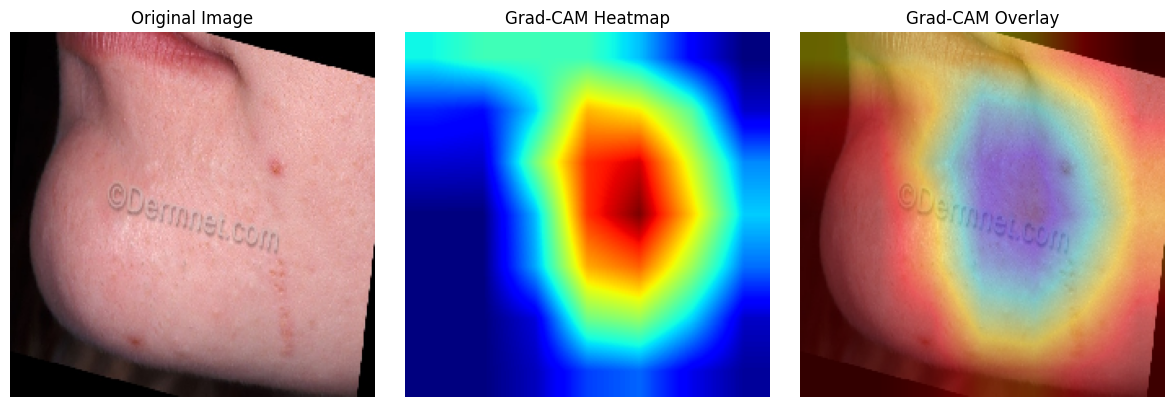

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Image path
image_path = "/content/drive/MyDrive/Dataset/test/Acne_Mild/aug_11_acne-closed-comedo-16.jpg"

# Load and preprocess image
img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img) / 255.0
input_image = np.expand_dims(img_array, axis=0)

# Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_image)
    predicted_index = tf.argmax(predictions[0])
    predicted_score = predictions[:, predicted_index]

# Gradients
grads = tape.gradient(predicted_score, conv_outputs)

# Global average pooling of gradients
pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

# Create heatmap
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[0][..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

# Resize heatmap
heatmap = cv2.resize(heatmap.numpy(), (224, 224))

# Convert to color heatmap
heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

# Convert original image to uint8
original = np.uint8(img_array * 255)

# Overlay
overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

# Prediction details
predicted_class = class_names[predicted_index.numpy()]
confidence = predictions[0][predicted_index].numpy() * 100

print("Actual Class: Acne_Mild")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def predict_skin_image(image_path):

    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Preprocess
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Original prediction
    original_prob = best_model.predict(
        img_array,
        verbose=0
    )

    # Horizontal flip prediction
    flipped_img = np.flip(img_array, axis=2)

    flipped_prob = best_model.predict(
        flipped_img,
        verbose=0
    )

    # Test-Time Augmentation
    final_prob = (original_prob + flipped_prob) / 2

    # Best prediction
    predicted_index = np.argmax(final_prob[0])
    predicted_class = class_names[predicted_index]
    confidence = final_prob[0][predicted_index] * 100

    # Separate disease and severity
    if predicted_class.startswith("Acne"):
        disease = "Acne"
        severity = predicted_class.replace("Acne_", "")

    elif predicted_class.startswith("Eczema"):
        disease = "Eczema"
        severity = predicted_class.replace("Eczema_", "")

    elif predicted_class == "Normal":
        disease = "Normal"
        severity = "None"

    else:
        disease = "Miscellaneous"
        severity = "Not Defined"

    return {
        "predicted_class": predicted_class,
        "disease": disease,
        "severity": severity,
        "confidence": confidence
    }

print("Final prediction pipeline created successfully!")

Final prediction pipeline created successfully!


Saving download.jpeg to download.jpeg
Uploaded Image:


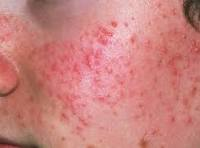


========== PREDICTION RESULT ==========
Disease   : Eczema
Severity  : Severe
Confidence: 37.42%


In [ ]:
from google.colab import files
from IPython.display import display
from PIL import Image

# Upload image
uploaded = files.upload()

# Get uploaded image path
image_path = list(uploaded.keys())[0]

# Display image
img = Image.open(image_path)

print("Uploaded Image:")
display(img)

# Predict
result = predict_skin_image(image_path)

print("\n========== PREDICTION RESULT ==========")
print("Disease   :", result["disease"])
print("Severity  :", result["severity"])
print(f"Confidence: {result['confidence']:.2f}%")
print("======================================")

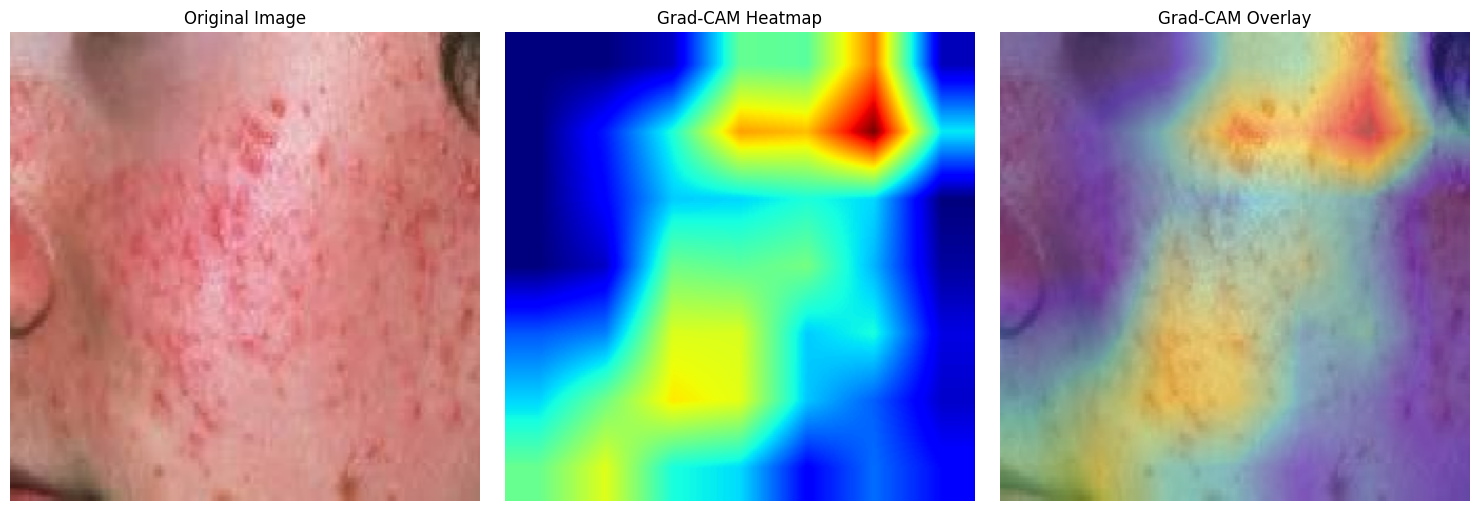

Grad-CAM generated successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Image path
img_path = "download.jpeg"

# Load image
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    predicted_index = tf.argmax(predictions[0])
    class_score = predictions[:, predicted_index]

grads = tape.gradient(class_score, conv_outputs)

# Average gradients
pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

# Create heatmap
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[0][..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.maximum(tf.reduce_max(heatmap), tf.keras.backend.epsilon())

# Resize heatmap
heatmap = tf.image.resize(
    heatmap[..., tf.newaxis],
    (224, 224)
).numpy().squeeze()

# Original image
original_img = np.array(img)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Grad-CAM generated succeSSssfully!")


Final TTA Prediction: Eczema_Severe
Confidence: 37.42%


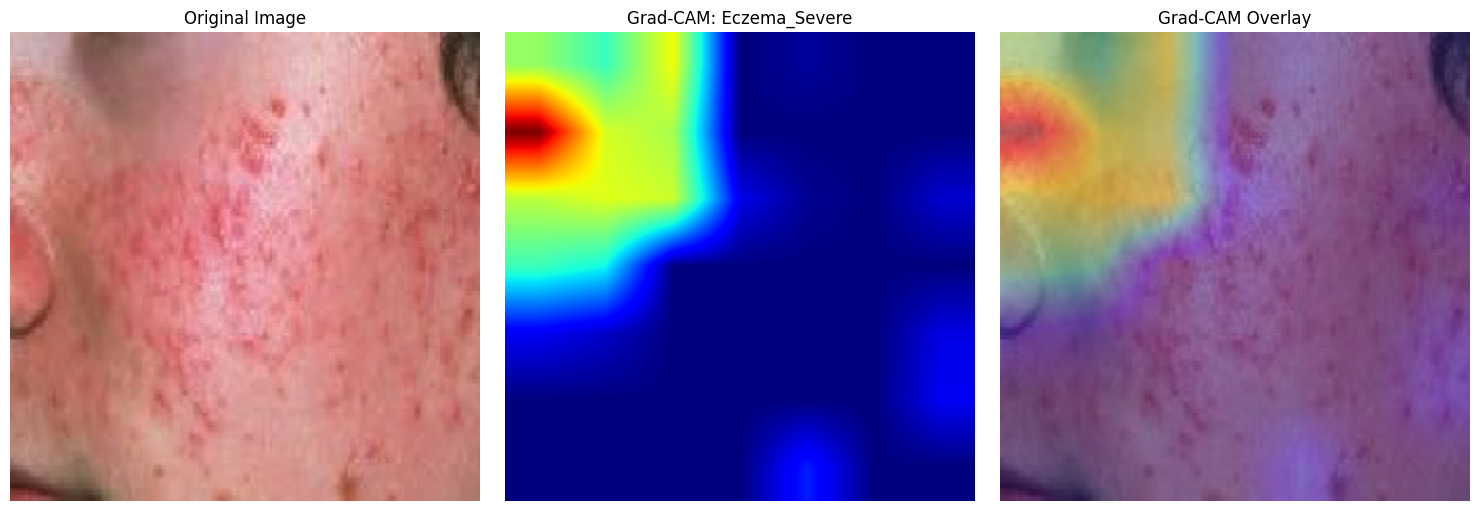

In [ ]:
# Use the SAME TTA prediction as our final prediction

original_prob = best_model.predict(img_array, verbose=0)

flipped_img = np.flip(img_array, axis=2)
flipped_prob = best_model.predict(flipped_img, verbose=0)

final_prob = (original_prob + flipped_prob) / 2

predicted_index = np.argmax(final_prob[0])
predicted_class = class_names[predicted_index]

print("Final TTA Prediction:", predicted_class)
print(f"Confidence: {final_prob[0][predicted_index] * 100:.2f}%")

# Grad-CAM for the SAME predicted class
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_score = predictions[:, predicted_index]

grads = tape.gradient(class_score, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[0][..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.maximum(tf.reduce_max(heatmap), tf.keras.backend.epsilon())

heatmap = tf.image.resize(
    heatmap[..., tf.newaxis],
    (224, 224)
).numpy().squeeze()

original_img = np.array(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title(f"Grad-CAM: {predicted_class}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

folder = "/content/drive/MyDrive/SkinCare_AI"
os.makedirs(folder, exist_ok=True)

best_model.save(folder + "/best_skin_model.keras")

print("Model saved successfully!")
print("Location:", folder + "/best_skin_model.keras")

Model saved successfully!
Location: /content/drive/MyDrive/SkinCare_AI/best_skin_model.keras
